# Código y Visualizaciones
# 📡 Telecom X — Análisis de Evasión de Clientes (Churn)
## Informe de Análisis Exploratorio de Datos (EDA)

**Analista:** Manuel Roldan
**Fecha:** 03/03/2026  
**Dataset:** TelecomX_Data.json — API Telecom X  


## 🎯 1. Introducción

Telecom X es una empresa de telecomunicaciones que enfrenta un alto índice de
evasión (*churn*) de clientes. Este proyecto tiene como objetivo identificar
los principales factores asociados a la cancelación del servicio, mediante un
análisis exploratorio de datos (EDA) que sirva de base para el desarrollo de
modelos predictivos.

**Problema:** Un alto porcentaje de clientes abandona el servicio sin que la
empresa conozca con precisión las causas, lo que genera pérdidas significativas
de ingresos recurrentes.

**Objetivos específicos:**
- 🔹 Importar y limpiar los datos desde la API.
- 🔹 Identificar patrones en los clientes que evaden.
- 🔹 Generar insights accionables para el equipo de negocio.

#📌 Primero la Extracción

In [17]:
# =====================================================
# CELDA 2: EXTRACCIÓN DE DATOS DESDE LA API
# =====================================================
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    response = requests.get(url, timeout=10)

    if response.status_code == 200:
        print("✅ Conexión exitosa con la API")
        data = response.json()

        # Convertir a DataFrame
        df = pd.json_normalize(data)

        print(f"✅ DataFrame creado correctamente")
        print(f"\n📊 Información del Dataset:")
        print(f"   • Filas    : {df.shape[0]:,}")
        print(f"   • Columnas : {df.shape[1]}")
        print(f"\n📋 Columnas disponibles:")
        for i, col in enumerate(df.columns, 1):
            print(f"   {i:2}. {col}")
    else:
        print(f"❌ Error HTTP: {response.status_code}")

except Exception as e:
    print(f"❌ Error de conexión: {e}")
    print("\n💡 Intenta ejecutar esta celda nuevamente")

# Verificar que df existe
try:
    print(f"\n✅ Variable 'df' disponible con {df.shape[0]} filas")
except:
    print("❌ La variable 'df' no se creó correctamente")



✅ Conexión exitosa con la API
✅ DataFrame creado correctamente

📊 Información del Dataset:
   • Filas    : 7,267
   • Columnas : 21

📋 Columnas disponibles:
    1. customerID
    2. Churn
    3. customer.gender
    4. customer.SeniorCitizen
    5. customer.Partner
    6. customer.Dependents
    7. customer.tenure
    8. phone.PhoneService
    9. phone.MultipleLines
   10. internet.InternetService
   11. internet.OnlineSecurity
   12. internet.OnlineBackup
   13. internet.DeviceProtection
   14. internet.TechSupport
   15. internet.StreamingTV
   16. internet.StreamingMovies
   17. account.Contract
   18. account.PaperlessBilling
   19. account.PaymentMethod
   20. account.Charges.Monthly
   21. account.Charges.Total

✅ Variable 'df' disponible con 7267 filas


## 📦 2. Importación de Librerías

In [18]:
# IMPORTAR LIBRERÍAS
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 🌐 2. Extracción de Datos desde la API

Los datos se obtienen directamente desde la API pública de Telecom X
en formato JSON y se convierten a un DataFrame de Pandas usando
`pd.json_normalize()` para aplanar la estructura anidada.

In [19]:
# =====================================================
# CELDA 4: DIAGNÓSTICO DE CALIDAD
# =====================================================

assert 'df' in dir(), "❌ ERROR: Ejecuta la Celda 2 primero"

print("=" * 55)
print("🔍 DIAGNÓSTICO DE CALIDAD DE DATOS")
print("=" * 55)

# Nulos
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
reporte = pd.DataFrame({'Nulos': nulos, 'Porcentaje(%)': pct})

print("\n📌 Valores Nulos:")
nulos_encontrados = reporte[reporte['Nulos'] > 0]
if len(nulos_encontrados) > 0:
    print(nulos_encontrados.sort_values('Nulos', ascending=False))
else:
    print("   ✅ No se encontraron valores nulos")

# Duplicados
duplicados = df.duplicated().sum()
print(f"\n📌 Filas duplicadas: {duplicados}")

# Valores únicos categóricos
print("\n📌 Valores únicos en columnas categóricas:")
for col in df.select_dtypes(include='object').columns:
    print(f"\n  🔹 {col}:")
    print(f"     {df[col].unique()}")

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
display(df.describe())

🔍 DIAGNÓSTICO DE CALIDAD DE DATOS

📌 Valores Nulos:
   ✅ No se encontraron valores nulos

📌 Filas duplicadas: 0

📌 Valores únicos en columnas categóricas:

  🔹 customerID:
     ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

  🔹 Churn:
     ['No' 'Yes' '']

  🔹 customer.gender:
     ['Female' 'Male']

  🔹 customer.Partner:
     ['Yes' 'No']

  🔹 customer.Dependents:
     ['Yes' 'No']

  🔹 phone.PhoneService:
     ['Yes' 'No']

  🔹 phone.MultipleLines:
     ['No' 'Yes' 'No phone service']

  🔹 internet.InternetService:
     ['DSL' 'Fiber optic' 'No']

  🔹 internet.OnlineSecurity:
     ['No' 'Yes' 'No internet service']

  🔹 internet.OnlineBackup:
     ['Yes' 'No' 'No internet service']

  🔹 internet.DeviceProtection:
     ['No' 'Yes' 'No internet service']

  🔹 internet.TechSupport:
     ['Yes' 'No' 'No internet service']

  🔹 internet.StreamingTV:
     ['Yes' 'No' 'No internet service']

  🔹 internet.StreamingMovies:
     ['No' 'Yes' 'No internet s

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


## 🔍 3. Exploración Inicial del Dataset

Antes de limpiar los datos, es fundamental entender su estructura:
tipos de datos, columnas disponibles y un vistazo general al contenido.

In [20]:
# Información general
print("=" * 55)
print("📋 ESTRUCTURA DEL DATASET")
print("=" * 55)
clientes_normalizado.info()

📋 ESTRUCTURA DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract         

In [6]:
# Primeras filas
print("📋 Primeras 5 filas:")
display(clientes_normalizado.head())

📋 Primeras 5 filas:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [21]:
# Estadísticas descriptivas iniciales
print("📊 Estadísticas descriptivas:")
display(clientes_normalizado.describe())

📊 Estadísticas descriptivas:


,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [22]:
# Valores únicos en columnas categóricas
print("📊 Valores únicos por columna categórica:\n")
for col in clientes_normalizado.select_dtypes(include='object').columns:
    print(f"  🔹 {col}: {clientes_normalizado[col].unique()}")

📊 Valores únicos por columna categórica:

  🔹 customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
  🔹 Churn: ['No' 'Yes' '']
  🔹 gender: ['Female' 'Male']
  🔹 Partner: ['Yes' 'No']
  🔹 Dependents: ['Yes' 'No']
  🔹 PhoneService: ['Yes' 'No']
  🔹 MultipleLines: ['No' 'Yes' 'No phone service']
  🔹 InternetService: ['DSL' 'Fiber optic' 'No']
  🔹 OnlineSecurity: ['No' 'Yes' 'No internet service']
  🔹 OnlineBackup: ['Yes' 'No' 'No internet service']
  🔹 DeviceProtection: ['No' 'Yes' 'No internet service']
  🔹 TechSupport: ['Yes' 'No' 'No internet service']
  🔹 StreamingTV: ['Yes' 'No' 'No internet service']
  🔹 StreamingMovies: ['No' 'Yes' 'No internet service']
  🔹 Contract: ['One year' 'Month-to-month' 'Two year']
  🔹 PaperlessBilling: ['Yes' 'No']
  🔹 PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
  🔹 Charges.Total: ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


## 🔎 4. Diagnóstico de Calidad de Datos

Se verifican tres tipos de problemas comunes:
- **Valores nulos**: datos faltantes que deben ser imputados o eliminados.
- **Duplicados**: filas repetidas que distorsionan el análisis.
- **Inconsistencias**: errores de formato, espacios en blanco, categorías mal escritas.

In [23]:
print("=" * 55)
print("🔍 DIAGNÓSTICO DE CALIDAD")
print("=" * 55)

# Valores nulos
nulos = clientes_normalizado.isnull().sum()
pct   = (nulos / len(clientes_normalizado) * 100).round(2)

reporte = pd.DataFrame({
    'Nulos'      : nulos,
    'Porcentaje' : pct
})

print("\n📌 Valores Nulos:")
print(reporte[reporte['Nulos'] > 0]
      .sort_values('Nulos', ascending=False)
      .to_string())

if reporte['Nulos'].sum() == 0:
    print("   ✅ No se encontraron valores nulos")

#  Duplicados
duplicados = clientes_normalizado.duplicated().sum()
print(f"\n📌 Filas duplicadas: {duplicados}")

# Shape
print(f"\n📌 Shape del dataset: {clientes_normalizado.shape}")

🔍 DIAGNÓSTICO DE CALIDAD

📌 Valores Nulos:
Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []
   ✅ No se encontraron valores nulos

📌 Filas duplicadas: 0

📌 Shape del dataset: (7267, 21)


## 🧹 5. Limpieza y Transformación de Datos

Se aplican las correcciones necesarias para garantizar la calidad del dataset:

1. Eliminación de duplicados
2. Imputación de valores nulos
3. Corrección de tipos de datos
4. Eliminación de espacios en blanco
5. Renombrado de columnas al español
6. Codificación binaria de variables categóricas (Yes/No → 1/0)
7. Creación de la variable `Cuentas_Diarias`

In [49]:
# Crear copia de trabajo
df_clean = df.copy()

# Eliminar duplicados

antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"✅ Duplicados eliminados: {antes - len(df_clean)}")

# Imputar valores nulos
# Numéricas → mediana
for col in df_clean.select_dtypes(include=['float64','int64']).columns:
    if df_clean[col].isnull().sum() > 0:
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f"  ✅ {col}: nulos → mediana ({mediana:.2f})")

# Categóricas → moda
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f"  ✅ {col}: nulos → moda ({moda})")


#  Corregir tipos de datos
# Use actual column names as they appear in df_clean before renaming
for col in ['account.Charges.Monthly', 'account.Charges.Total', 'customer.tenure']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Limpiar espacios en blanco

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

print("\n✅ Limpieza completada")
print(f"📊 Shape después de limpieza: {df_clean.shape}")

✅ Duplicados eliminados: 0

✅ Limpieza completada
📊 Shape después de limpieza: (7267, 21)


In [14]:
# Para simplificar el código, definimos df como clientes_normalizado
df = clientes_normalizado

In [ ]:

# Renombrar columnas al español
renombrar = {
    'customerID'           : 'ID_Cliente',
    'gender'               : 'Genero',
    'SeniorCitizen'        : 'Adulto_Mayor',
    'Partner'              : 'Tiene_Pareja',
    'Dependents'           : 'Tiene_Dependientes',
    'tenure'               : 'Meses_Contrato',
    'PhoneService'         : 'Servicio_Telefono',
    'MultipleLines'        : 'Multiples_Lineas',
    'InternetService'      : 'Servicio_Internet',
    'OnlineSecurity'       : 'Seguridad_Online',
    'OnlineBackup'         : 'Backup_Online',
    'DeviceProtection'     : 'Proteccion_Dispositivo',
    'TechSupport'          : 'Soporte_Tecnico',
    'StreamingTV'          : 'Streaming_TV',
    'StreamingMovies'      : 'Streaming_Peliculas',
    'Contract'             : 'Tipo_Contrato',
    'PaperlessBilling'     : 'Factura_Digital',
    'PaymentMethod'        : 'Metodo_Pago',
    'Charges.Monthly'      : 'Cargo_Mensual',
    'Charges.Total'        : 'Cargo_Total',
    'Churn'                : 'Evasion'
}

cols_existentes = {k: v for k, v in renombrar.items()
                   if k in df_clean.columns}
df_clean = df_clean.rename(columns=cols_existentes)
print("✅ Columnas renombradas al español")

In [35]:
# Codificación binaria Yes/No → 1/0

# Ensure 'Churn' is included for encoding as it's the target variable
binarias = [
    'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'account.PaperlessBilling', 'Churn'
] # Updated to use original column names before renaming, and included 'Churn'

for col in binarias:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(
            {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
        ).fillna(df_clean[col])

# Handle the empty string in Churn if it's still present after initial mapping
if 'Churn' in df_clean.columns:
    df_clean['Churn'] = df_clean['Churn'].replace('', np.nan) # Replace empty string with NaN
    df_clean['Churn'] = pd.to_numeric(df_clean['Churn'], errors='coerce') # Ensure numeric type
    df_clean['Churn'].fillna(0, inplace=True) # Impute NaN (empty strings) as 'No churn' (0)

print("✅ Variables binarias codificadas (Yes=1 / No=0)")

# Crear columna Cuentas_Diarias
if 'account.Charges.Monthly' in df_clean.columns:
    df_clean['Cuentas_Diarias'] = (df_clean['account.Charges.Monthly'] / 30).round(4)
    print("✅ Columna 'Cuentas_Diarias' creada")

# Vista final
print(f"\n📊 Dataset limpio y listo:")
print(f"   • Filas    : {df_clean.shape[0]:,}")
print(f"   • Columnas : {df_clean.shape[1]}")
display(df_clean.head())

✅ Variables binarias codificadas (Yes=1 / No=0)
✅ Columna 'Cuentas_Diarias' creada

📊 Dataset limpio y listo:
   • Filas    : 7,267
   • Columnas : 22


/tmp/ipykernel_616/3208033749.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Churn'] = df_clean['Churn'].replace('', np.nan) # Replace empty string with NaN
/tmp/ipykernel_616/3208033749.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Churn'].fillna(0, inplace=True) # 

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3,2.1867
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.4,1.9967
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.4633
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.2667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.4,2.7967


## 📊 6. Análisis Exploratorio de Datos (EDA)

### 6.1 Distribución de la Variable Target — Evasión

Se analiza cuántos clientes permanecieron y cuántos cancelaron el servicio.

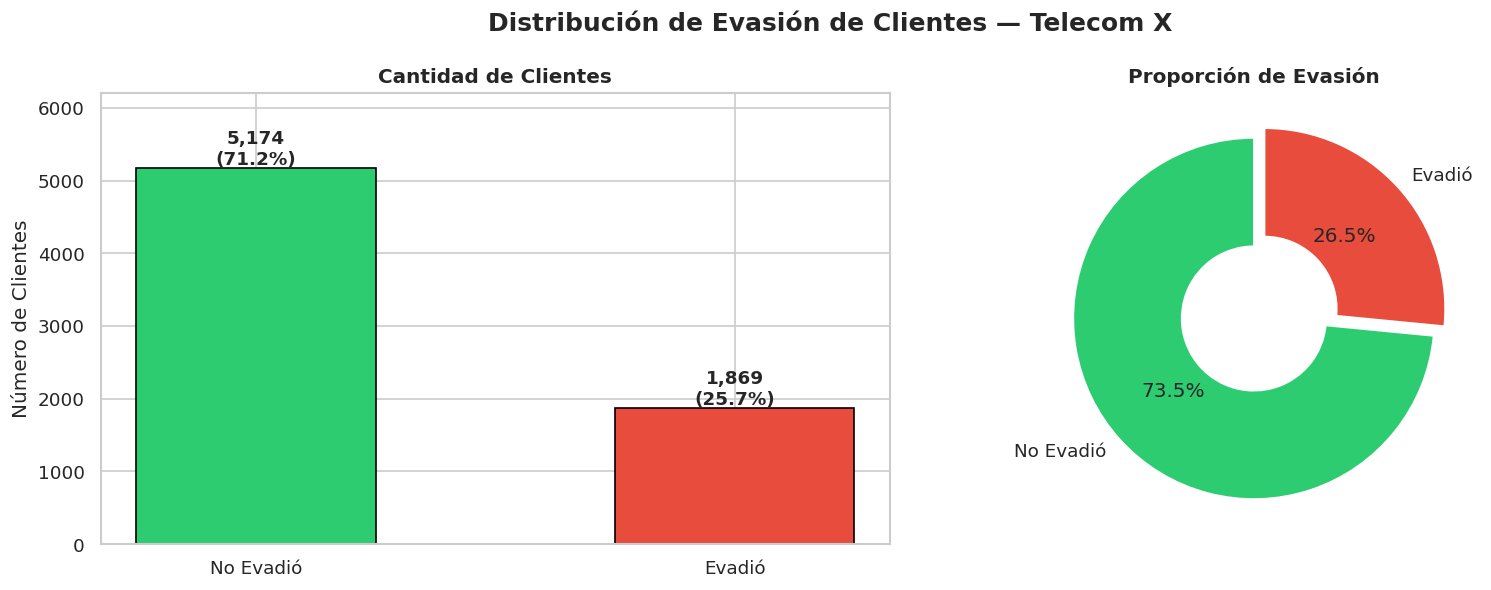

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Evasión de Clientes — Telecom X',
             fontsize=15, fontweight='bold')

conteo   = df_clean['Churn'].value_counts() # Changed 'Evasion' to 'Churn'
# Filter out the empty string '' from conteo if it exists
if '' in conteo.index:
    conteo = conteo.drop('')

etiquetas = ['No Evadió', 'Evadió']
colores   = ['#2ecc71', '#e74c3c']

# Ensure conteo values are in the correct order for labels
no_churn_count = conteo.get('No', 0)
yes_churn_count = conteo.get('Yes', 0)
conteo_values_for_plot = np.array([no_churn_count, yes_churn_count])

# Barras
bars = axes[0].bar(etiquetas, conteo_values_for_plot,
                   color=colores, edgecolor='black', width=0.5)
axes[0].set_title('Cantidad de Clientes', fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
axes[0].set_ylim(0, conteo_values_for_plot.max() * 1.2)
for bar, val in zip(bars, conteo_values_for_plot):
    pct = val / len(df_clean) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

# Dona
axes[1].pie(conteo_values_for_plot,
            labels=etiquetas,
            colors=colores,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.08),
            wedgeprops=dict(width=0.6))
axes[1].set_title('Proporción de Evasión', fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribucion_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Evasión por Variables Categóricas

Se analiza la tasa de evasión según variables como género, tipo de
contrato, método de pago, entre otras, para identificar perfiles de riesgo.

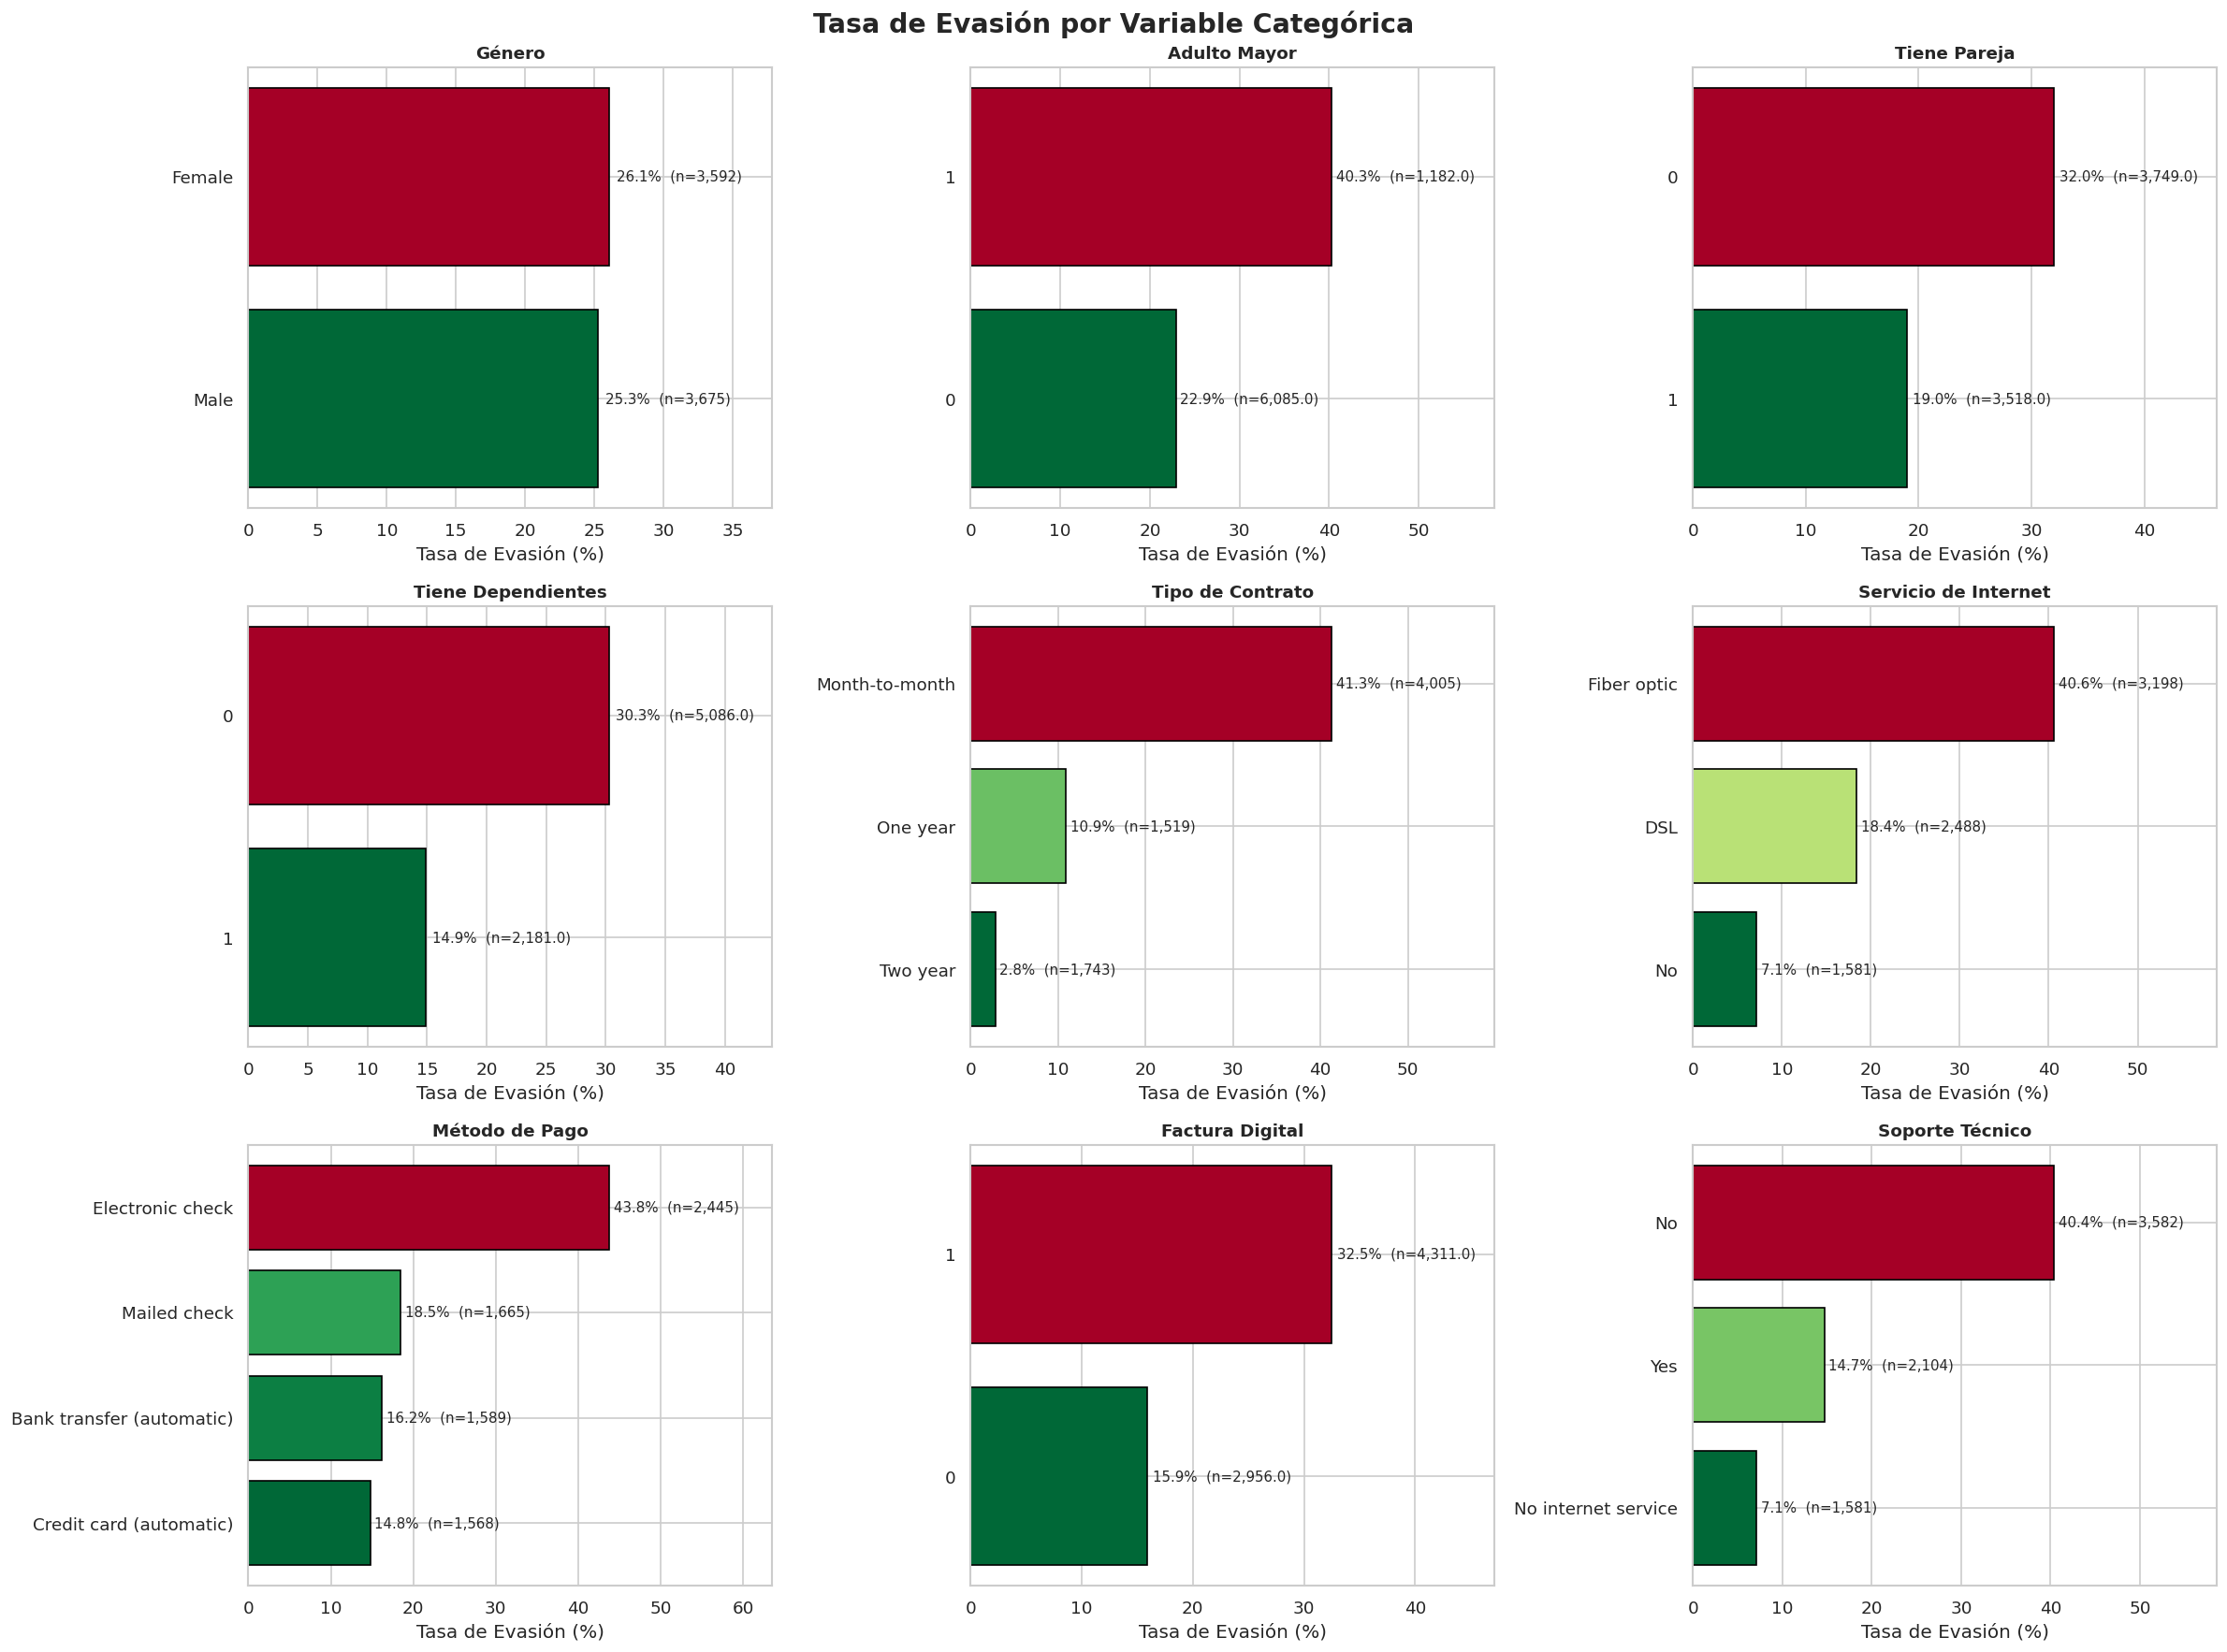

In [37]:
categoricas_map = {
    'customer.gender'        : 'Género',
    'customer.SeniorCitizen' : 'Adulto Mayor',
    'customer.Partner'       : 'Tiene Pareja',
    'customer.Dependents'    : 'Tiene Dependientes',
    'account.Contract'       : 'Tipo de Contrato',
    'internet.InternetService': 'Servicio de Internet',
    'account.PaymentMethod'  : 'Método de Pago',
    'account.PaperlessBilling': 'Factura Digital',
    'internet.TechSupport'   : 'Soporte Técnico'
}

# Solo columnas que existen en el DataFrame con sus nombres actuales
categoricas = {k: v for k, v in categoricas_map.items()
               if k in df_clean.columns}

n    = len(categoricas)
cols = 3
rows = (n + cols - 1) // cols

# Handle case where no categorical columns are found (should not happen with the above fix)
if rows == 0 and n > 0: # Ensure rows is at least 1 if there are categories
    rows = 1
elif n == 0:
    print("No se encontraron columnas categóricas para graficar.")
    # Exit or handle this case appropriately, e.g., show an empty plot or skip
    # For now, we'll just return.
    # raise ValueError("No categorical columns to plot after filtering.")
    # If no categories, we don't need to proceed with plotting
    plt.close('all') # Close any created figures if no plots will be made
    exit() # Or use return to stop execution of this cell


fig, axes = plt.subplots(rows, cols,
                         figsize=(20, rows * 5))
fig.suptitle('Tasa de Evasión por Variable Categórica',
             fontsize=17, fontweight='bold')
axes_flat = axes.flatten()

for idx, (col, titulo) in enumerate(categoricas.items()):
    ax = axes_flat[idx]

    # Use 'Churn' as the target column since 'Evasion' is not yet present
    grupo = (df_clean.groupby(col)
             .agg(Tasa=('Churn','mean'), # Changed 'Evasion' to 'Churn'
                  Total=('Churn','count')) # Changed 'Evasion' to 'Churn'
             .reset_index())
    grupo['Tasa'] = (grupo['Tasa'] * 100).round(1)
    grupo = grupo.sort_values('Tasa', ascending=True)

    norm   = plt.Normalize(grupo['Tasa'].min(), grupo['Tasa'].max())
    colors = plt.cm.RdYlGn_r(norm(grupo['Tasa']))

    bars = ax.barh(grupo[col].astype(str),
                   grupo['Tasa'],
                   color=colors, edgecolor='black')

    for bar, (_, row) in zip(bars, grupo.iterrows()):
        ax.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height()/2,
                f"{row['Tasa']}%  (n={row['Total']:,})",
                va='center', fontsize=9)

    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Tasa de Evasión (%)')
    ax.set_xlim(0, grupo['Tasa'].max() * 1.45)

for j in range(len(categoricas), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('02_evasion_categoricas.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Evasión por Variables Numéricas

Se compara la distribución de variables como antigüedad, cargos
mensuales y totales entre clientes que evadieron y los que no.

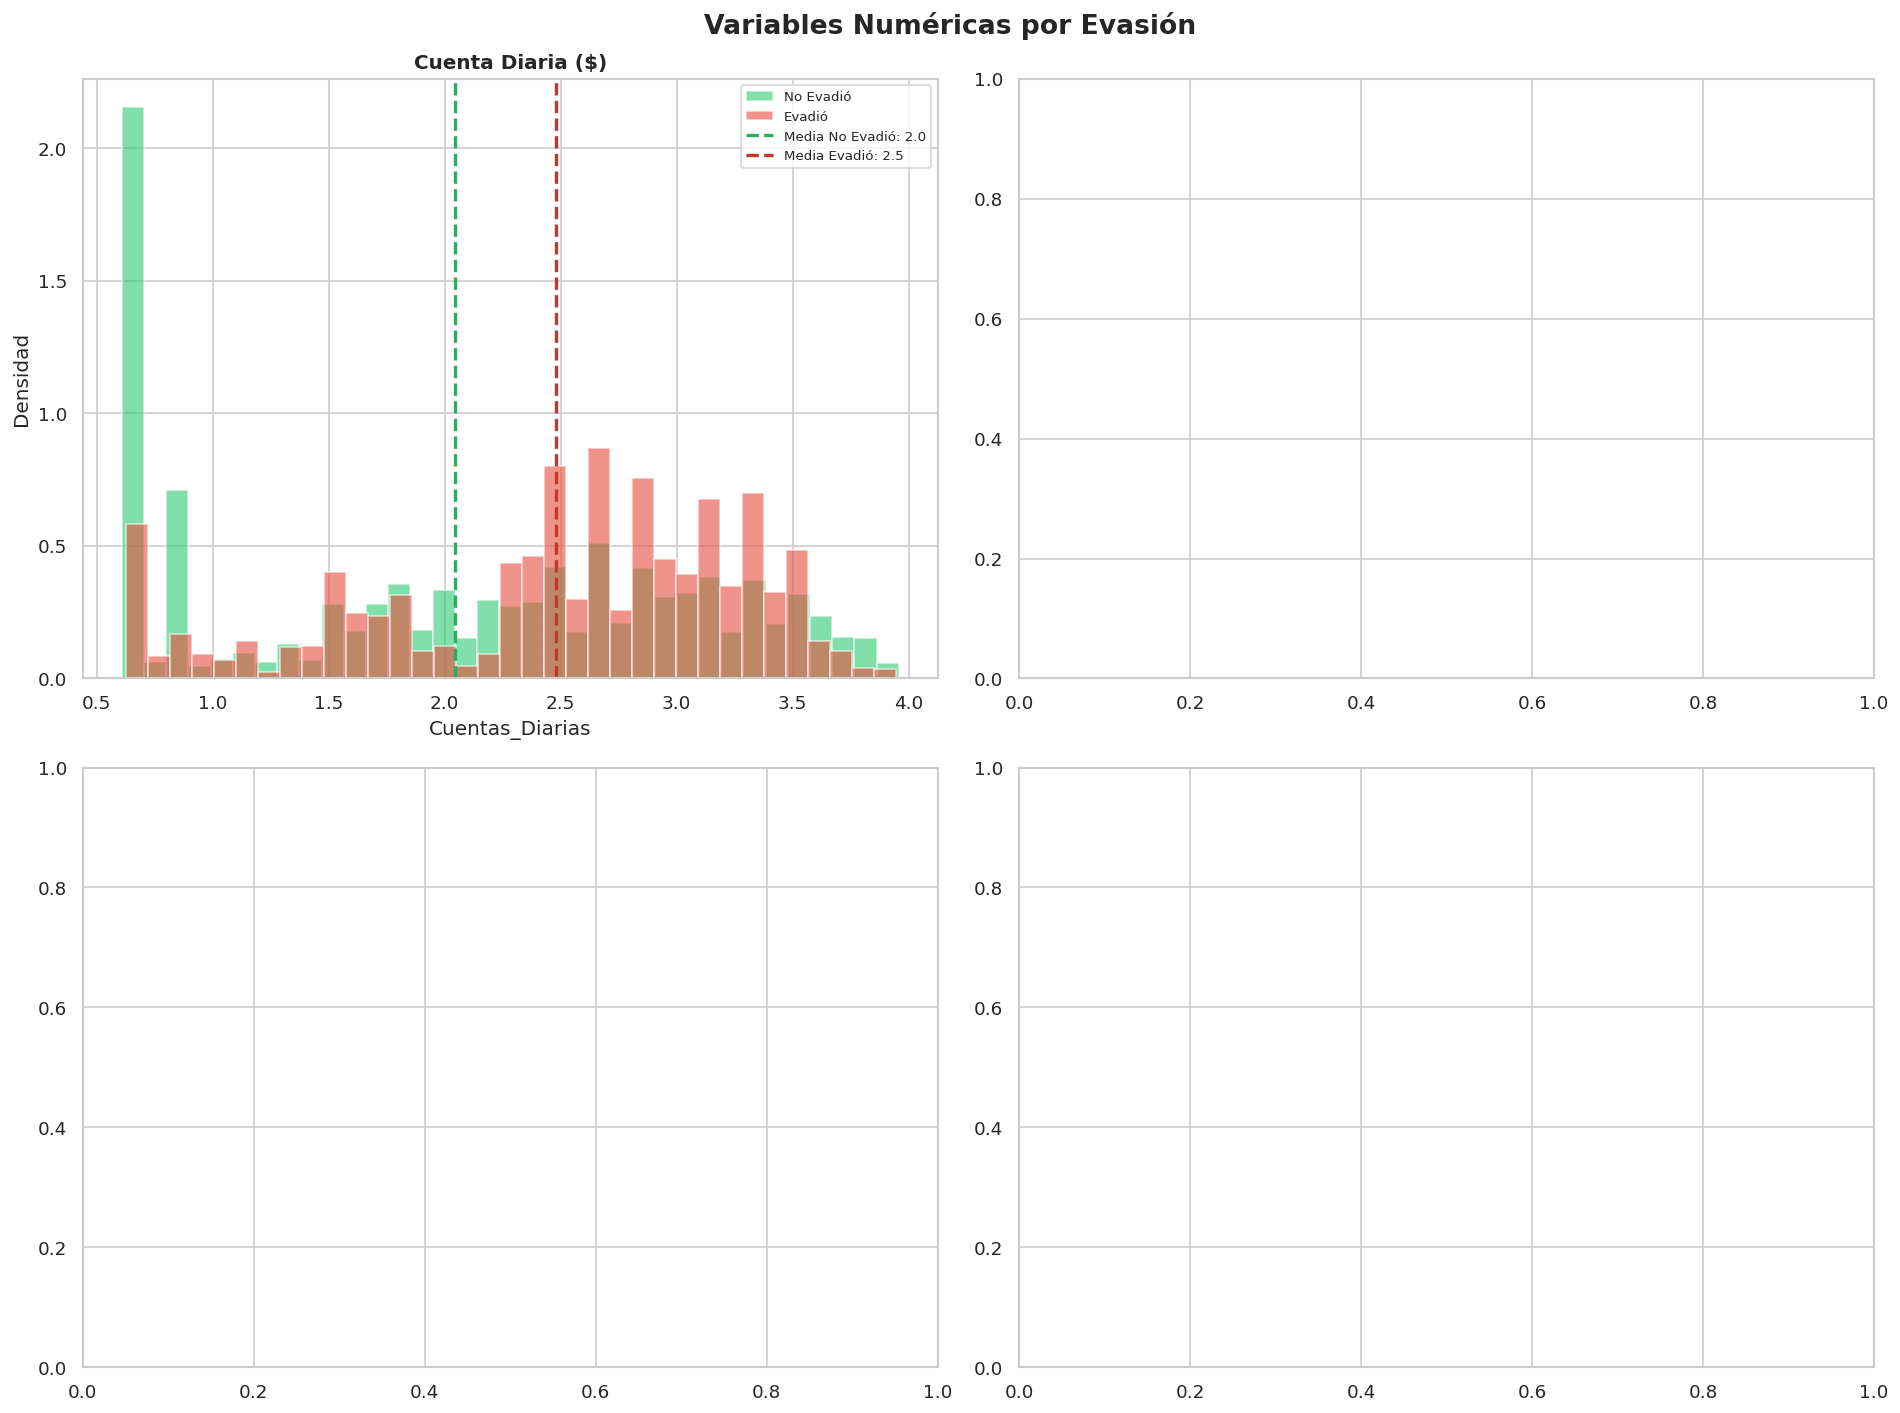

In [40]:
numericas = {
    'Meses_Contrato'  : 'Meses de Contrato',
    'Cargo_Mensual'   : 'Cargo Mensual ($)',
    'Cargo_Total'     : 'Cargo Total ($)',
    'Cuentas_Diarias' : 'Cuenta Diaria ($)'
}
numericas = {k: v for k, v in numericas.items()
             if k in df_clean.columns}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Variables Numéricas por Evasión',
             fontsize=16, fontweight='bold')

for idx, (col, titulo) in enumerate(numericas.items()):
    ax = axes.flatten()[idx]

    g0 = df_clean[df_clean['Churn']==0][col].dropna()
    g1 = df_clean[df_clean['Churn']==1][col].dropna()

    ax.hist(g0, bins=35, alpha=0.6,
            color='#2ecc71', label='No Evadió',
            edgecolor='white', density=True)
    ax.hist(g1, bins=35, alpha=0.6,
            color='#e74c3c', label='Evadió',
            edgecolor='white', density=True)

    ax.axvline(g0.mean(), color='#27ae60',
               linestyle='--', linewidth=2,
               label=f'Media No Evadió: {g0.mean():.1f}')
    ax.axvline(g1.mean(), color='#c0392b',
               linestyle='--', linewidth=2,
               label=f'Media Evadió: {g1.mean():.1f}')

    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('03_numericas_histograma.png',
            dpi=150, bbox_inches='tight')
plt.show()

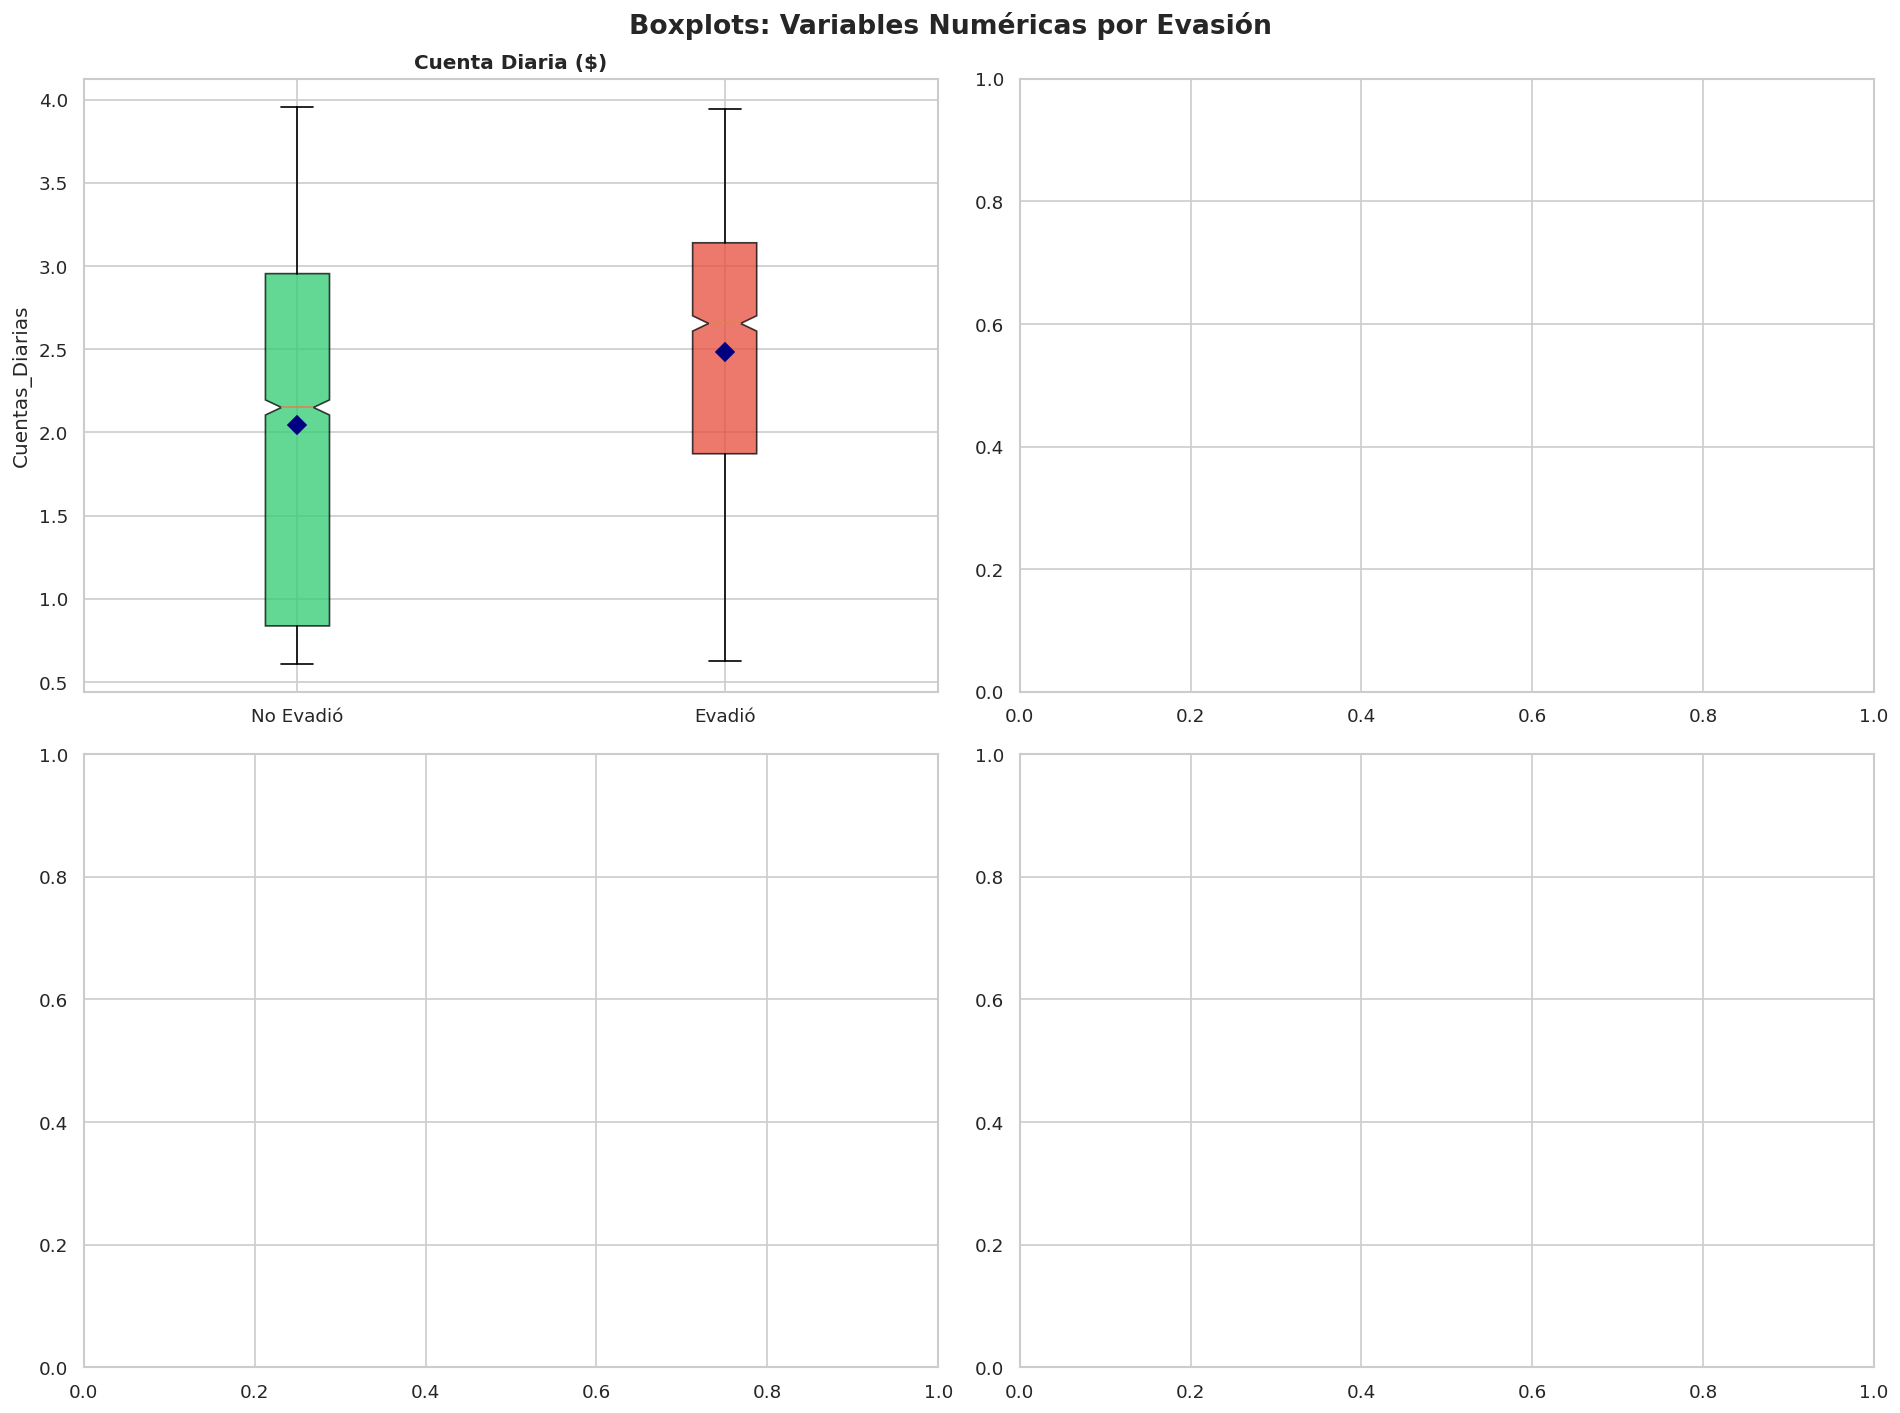

In [44]:
# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Boxplots: Variables Numéricas por Evasión',
             fontsize=16, fontweight='bold')

for idx, (col, titulo) in enumerate(numericas.items()):
    ax = axes.flatten()[idx]

    g0 = df_clean[df_clean['Churn']==0][col].dropna()
    g1 = df_clean[df_clean['Churn']==1][col].dropna()

    bp = ax.boxplot([g0, g1],
                    tick_labels=['No Evadió','Evadió'], # Changed 'labels' to 'tick_labels'
                    patch_artist=True,
                    notch=True)

    for patch, color in zip(bp['boxes'],['#2ecc71','#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Punto de la media
    for i, grupo in enumerate([g0, g1], 1):
        ax.plot(i, grupo.mean(), 'D',
                color='navy', markersize=8, zorder=5)

    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Análisis de Correlación (Opcional)

Se explora la relación entre todas las variables numéricas y
su correlación con la variable objetivo (Evasión).

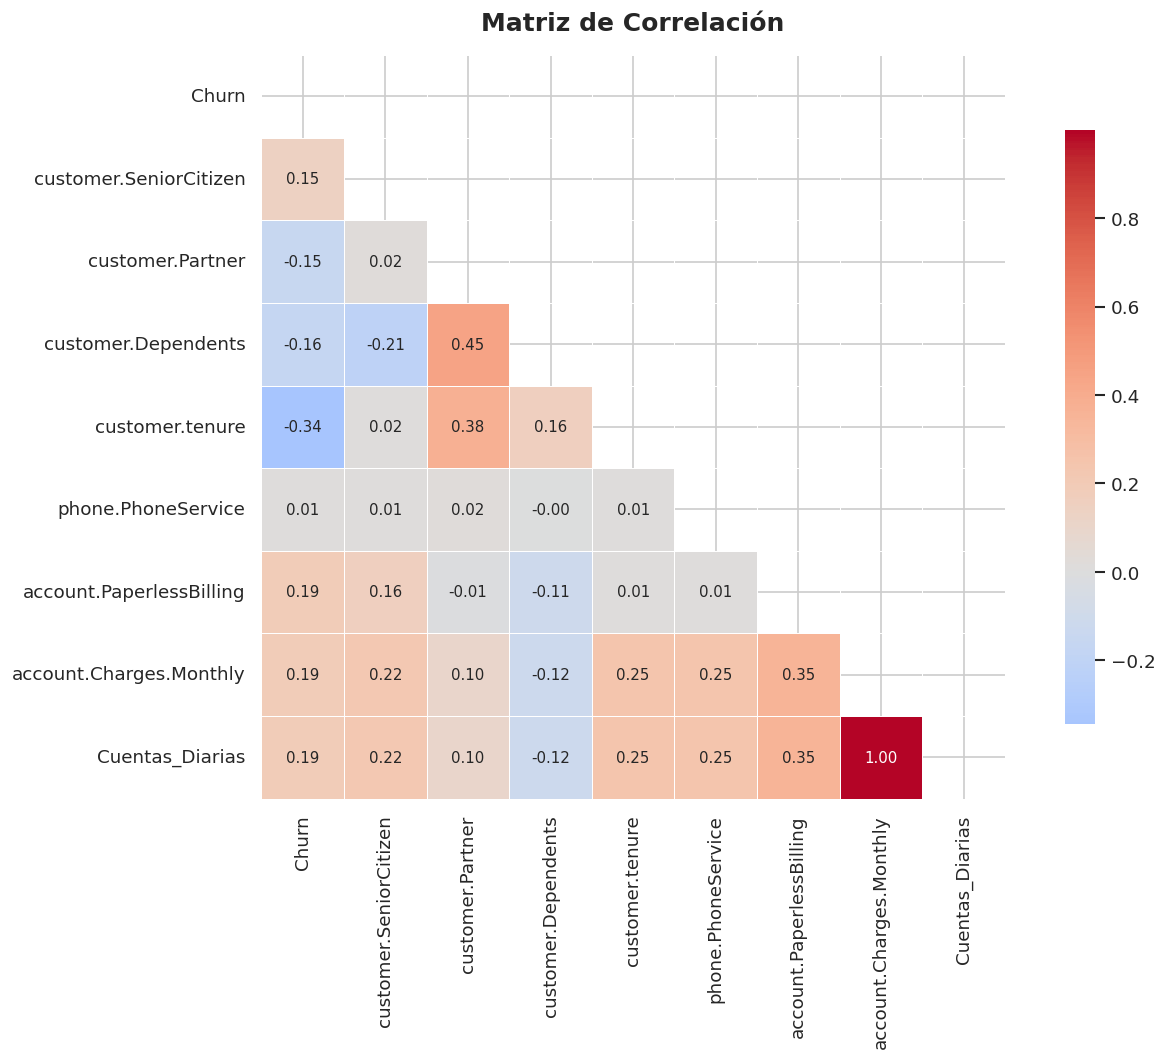

In [45]:
# Matriz de correlación
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr     = df_clean[num_cols].corr()
mask     = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8},
            ax=ax)
ax.set_title('Matriz de Correlación',
             fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('05_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

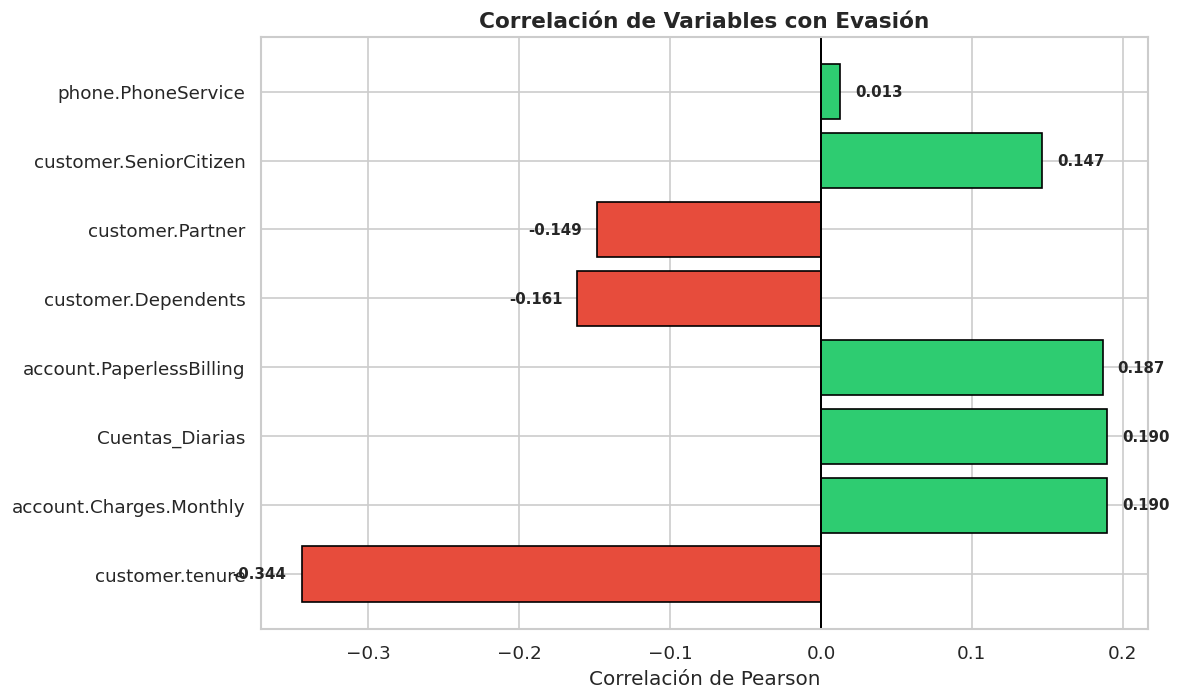

In [50]:
# Correlación específica con Evasión
corr_evasion = (corr['Churn']
                .drop('Churn')
                .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71'
          for v in corr_evasion.values]

bars = ax.barh(corr_evasion.index,
               corr_evasion.values,
               color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Correlación de Variables con Evasión',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Correlación de Pearson')

for bar, val in zip(bars, corr_evasion.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('06_corr_evasion.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones e Insights

**Acerca del usuario promedio de Telecom X:**

En general, los clientes en Telecom X muestran una retención bastante saludable. Aquellos usuarios que permanecen lo hacen por una cantidad significativa de tiempo, invirtiendo una considerable cantidad de recursos.

Estamos hablando de un promedio de **32.35 meses** que el usuario se queda en la empresa (`Meses_Contrato`), pagando un plan mensual de aproximadamente **$64.72** (`Cargo_Mensual`) y llegando a un **total promedio de $2093.07 invertido** (`Cargo_Total`).

Lo más contratado por estos usuarios son los servicios telefónicos, prefiriendo contratos mensuales, aunque estos últimos son los que presentan mayor riesgo de evasión.

**Acerca del usuario evasor de Telecom X:**

El perfil de un usuario propenso a la evasión en Telecom X se caracteriza por:

*   **Meses de Contrato (Tenure):** Un promedio de **18.06 meses** de servicio, lo que sugiere que los clientes con menor antigüedad son más vulnerables. Esto contrasta fuertemente con los 38 meses de los clientes que no evaden.
*   **Cargo Mensual:** Tienden a tener **cargos mensuales más altos**, con un promedio de **$80.12**.
*   **Tipo de Contrato:** Prefieren los **contratos 'Mes a mes'**.
*   **Servicio de Internet:** Utilizan con frecuencia el servicio de **Fibra Óptica**.
*   **Método de Pago:** Paga con **cheque electrónico**.
*   **Factura:** Utiliza la **Factura Digital**.
*   **Soporte Técnico:** No suelen tener servicio de **Soporte Técnico**.

Estos son los usuarios más propensos a abandonar Telecom X, presentando un riesgo clave para la empresa.

### Recomendaciones

Las recomendaciones se centran en dos estrategias clave para fomentar la retención, considerando que los usuarios con más de ~18 meses (y especialmente más de 32 meses) o que no pagan con cheque electrónico son menos propensos a abandonar la empresa:

1.  **Ofrecer Contratos de Mediano Plazo (ej. 1/2 año):**
    *   Este tipo de contrato es clave para la retención, especialmente para usuarios que actualmente optan por el 'Mes a mes'. Ofrecer una opción intermedia podría mejorar significativamente la retención de usuarios nuevos y actuales.
    *   Para evitar que este contrato afecte negativamente a las opciones más largas, podría ser aplicado **una sola vez** para los clientes. Al finalizar el plazo, se les podría incentivar a tomar contratos más extensos (1 o 2 años).
    *   Es importante considerar cómo se aplicaría este contrato a los usuarios antiguos y realizar un análisis posterior para observar cómo los nuevos usuarios adoptan o abandonan este contrato.

2.  **Evaluar los Pagos con Cheque Electrónico:**
    *   Es fundamental investigar las razones detrás de la alta tasa de evasión entre los usuarios que pagan con cheque electrónico. Realizar encuestas o análisis cualitativos podría revelar problemas con la plataforma, la usabilidad o la percepción de seguridad.
    *   Con esta información, se podría mejorar el soporte a los usuarios que eligen este método de pago y buscar formas de incentivarlos a adoptar métodos más estables, o bien mejorar la experiencia con el cheque electrónico para reducir el riesgo de abandono.